# CNN + 標準化

## 載入套件

In [ ]:
import math, sys
from pathlib import Path
from typing import Sized, cast

import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage import io
from skimage.transform import resize
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

## 設定參數

In [ ]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
BATCH_SIZE = 1024  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 步驟1：載入 MNIST 手寫阿拉伯數字資料

In [3]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.1307,), std=(0.3081,))])

# 下載 MNIST 手寫阿拉伯數字 訓練資料
train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=transform)

# 下載測試資料
test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=transform)

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


## 步驟2：資料清理，此步驟無需進行

## 步驟3：進行特徵工程，將特徵縮放成(0, 1)之間

In [4]:
# train_ds.data = train_ds.data / 255.0
# test_ds.data = test_ds.data / 255.0

## 步驟4：資料分割，此步驟無需進行，載入MNIST資料時，已經切割好了

## 步驟5：建立模型結構

In [5]:
# W, F, P, S：image Width, Filter width, Padding, Stride
# def Conv_Width(W, F, P, S):
#     return math.floor(((W - F) + 2 * P) / S) + 1

# # def Pool_Width(W, F, S):
#     return math.floor((W - F) / S) + 1


def Conv_Width(W: int, F: int, P: int, S: int) -> int:
    return math.floor(((W - F + 2 * P) / S) + 1)


def Conv_Output_Volume(W: int, F: int, P: int, S: int, out: int) -> int:
    return Conv_Width(W, F, P, S) ** 2 * out


# C: no of channels
def Conv_Parameter_Count(F: int, C: int, out: int) -> int:
    return F**2 * C * out


def Pool_Width(W: int, F: int, P: int, S: int) -> int:
    return Conv_Width(W, F, P, S)


# filter_count: no of filter in last conv
# stride count default value = Filter width
def Pool_Output_Volume(W: int, F: int, P: int, S: int, filter_count: int) -> int:
    return Conv_Output_Volume(W, F, P, S, filter_count)


def Pool_Parameter_Count(W: int, F: int, S: int) -> int:
    return 0


def Conv_Pool_Width(W: int, F: int, P: int, S: int, F2: int, P2: int, S2: int, n: int) -> int:
    for i in range(n):
        W = Pool_Width(Conv_Width(W, F, P, S), F2, P2, S2)
    return W

In [6]:
# ConvNet2
l2_Width = Conv_Width(Conv_Width(28, 3, 0, 1), 3, 0, 1)
p1_out = Pool_Output_Volume(l2_Width, 2, 0, 2, 64)
l2_Width, p1_out

(24, 9216)

## 步驟6：結合訓練資料及模型，進行模型訓練

In [7]:
# Conv2d 參數： in-channel, out-channel, kernel size, Stride, Padding
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x: torch.Tensor):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

In [8]:
def train(
    model: nn.Module,
    device: str,
    train_loader: DataLoader,
    optimizer: optim.Optimizer,
    epoch: int,
) -> list[float]:
    model.train()
    loss_list: list[float] = []
    data: torch.Tensor
    target: torch.Tensor
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output: torch.Tensor = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        if (batch_idx + 1) % 10 == 0:
            loss_list.append(loss.item())
            batch = (batch_idx + 1) * len(data)
            data_count = len(cast(Sized, train_loader.dataset))
            percentage = 100.0 * (batch_idx + 1) / len(cast(Sized, train_loader.dataset))
            print(f'Epoch {epoch}: [{batch:5d} / {data_count}] ({percentage:.0f} %)  Loss: {loss.item():.6f}')
    return loss_list

In [9]:
def test(model: nn.Module, device: str, test_loader: DataLoader) -> None:
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        data: torch.Tensor
        target: torch.Tensor
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output: torch.Tensor = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    # 平均損失
    test_loss /= len(cast(Sized, test_loader.dataset))
    # 顯示測試結果
    data_count = len(cast(Sized, test_loader.dataset))
    percentage = 100.0 * correct / data_count
    print(f'平均損失: {test_loss:.4f}, 準確率: {correct}/{data_count} ({percentage:.2f}%)\n')

In [10]:
epochs = 10
lr = 0.1

# 改變批量以縮短訓練時間
train_loader = DataLoader(train_ds, shuffle=True, batch_size=600)

# 建立模型
model = Net().to(device)

# 設定優化器(optimizer)
optimizer = optim.Adadelta(model.parameters(), lr=lr)

loss_list = []
for epoch in range(1, epochs + 1):
    loss_list += train(model, device, train_loader, optimizer, epoch)
    # test(model, device, test_loader)
    optimizer.step()

Epoch 1: [ 6000 / 100] (10 %)  Loss: 1.778226
Epoch 1: [12000 / 100] (20 %)  Loss: 1.077987
Epoch 1: [18000 / 100] (30 %)  Loss: 0.776123
Epoch 1: [24000 / 100] (40 %)  Loss: 0.581054
Epoch 1: [30000 / 100] (50 %)  Loss: 0.534085
Epoch 1: [36000 / 100] (60 %)  Loss: 0.447655
Epoch 1: [42000 / 100] (70 %)  Loss: 0.462290
Epoch 1: [48000 / 100] (80 %)  Loss: 0.400419
Epoch 1: [54000 / 100] (90 %)  Loss: 0.430418
Epoch 1: [60000 / 100] (100 %)  Loss: 0.358207
Epoch 2: [ 6000 / 100] (10 %)  Loss: 0.340385
Epoch 2: [12000 / 100] (20 %)  Loss: 0.349364
Epoch 2: [18000 / 100] (30 %)  Loss: 0.323534
Epoch 2: [24000 / 100] (40 %)  Loss: 0.290881
Epoch 2: [30000 / 100] (50 %)  Loss: 0.334335
Epoch 2: [36000 / 100] (60 %)  Loss: 0.324607
Epoch 2: [42000 / 100] (70 %)  Loss: 0.296052
Epoch 2: [48000 / 100] (80 %)  Loss: 0.230287
Epoch 2: [54000 / 100] (90 %)  Loss: 0.272731
Epoch 2: [60000 / 100] (100 %)  Loss: 0.276647
Epoch 3: [ 6000 / 100] (10 %)  Loss: 0.232489
Epoch 3: [12000 / 100] (20 %)  L

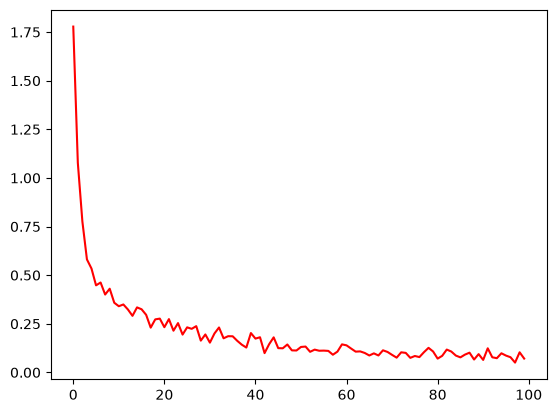

In [11]:
# 對訓練過程的損失繪圖
plt.plot(loss_list, 'r')

## 步驟7：評分(Score Model)

In [12]:
# 建立 DataLoader
test_loader = DataLoader(test_ds, shuffle=False, batch_size=BATCH_SIZE)

# 評分
test(model, device, test_loader)

平均損失: 0.0516, 準確率: 9843/10000 (98.43%)



In [13]:
# 實際預測 20 筆資料
predictions = []
with torch.no_grad():
    for i in range(20):
        data: torch.Tensor = test_ds[i][0]
        data = data.reshape(1, *data.shape).to(device)
        output = torch.argmax(model(data), dim=-1)
        predictions.append(str(output.item()))

# 比對
print('actual    :', test_ds.targets[0:20].numpy())
print('prediction: ', ' '.join(predictions[0:20]))

actual    : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
prediction:  7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4


In [14]:
# 顯示第 9 筆的機率
i = 8
data: torch.Tensor = test_ds[i][0]
data = data.reshape(1, *data.shape).to(device)
print(data.shape)
predictions = torch.softmax(model(data), dim=1)
print(f'0~9預測機率: {np.around(predictions.cpu().detach().numpy(), 2)}')
print(f'0~9預測機率: {np.argmax(predictions.cpu().detach().numpy(), axis=-1)}')

torch.Size([1, 1, 28, 28])
0~9預測機率: [[0.   0.   0.   0.   0.   0.88 0.12 0.   0.   0.  ]]
0~9預測機率: [5]


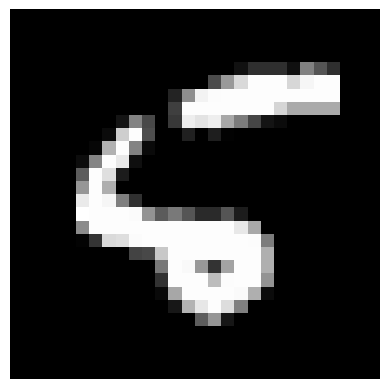

In [15]:
# 顯示第 9 筆圖像
X2: torch.Tensor = test_ds[i][0]
plt.imshow(X2.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

In [16]:
test_ds[i][0]

tensor([[[-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242],
         [-0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242, -0.4242,
          -0.4242, -0.4242, -0.4242, -0.4242, -0

## 步驟8：評估，暫不進行

## 步驟9：模型佈署

In [17]:
# 模型存檔
torch.save(model, 'cnn_mnist_normal.pth')

# 模型載入
model: Net = torch.load('cnn_mnist_normal.pth', weights_only=False)

## 步驟10：新資料預測

In [18]:
# 使用小畫家，繪製 0~9，實際測試看看
no = 7
uploaded_file = f'myDigits/{no}.png'
image1 = io.imread(uploaded_file, as_gray=True)

# 縮為 (28, 28) 大小的影像
data_shape = data.shape
image_resized = np.asarray(resize(image1, data_shape[2:], anti_aliasing=True))
X1 = image_resized.reshape(*data_shape)

# 反轉顏色，顏色0為白色，與 RGB 色碼不同，它的 0 為黑色
X1 = 1.0 - X1

# 圖像轉換
X1 = (X1 - 0.1307) / 0.3081

for i in range(X1[0][0].shape[0]):
    for j in range(X1[0][0].shape[1]):
        print(f'{X1[0][0][i][j]:.4f}', end=' ')
    print()

-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 
-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 
-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 
-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4241 -0.4238 -0.4240 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 
-0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4242 -0.4128 -0.2873 -0.1876 -0.2

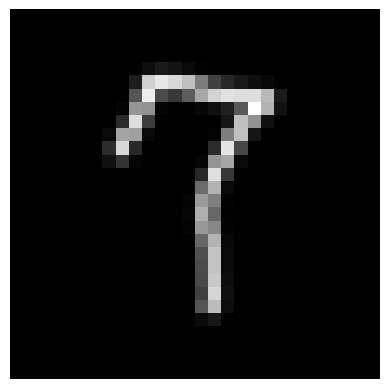

In [19]:
# 顯示第1張圖片圖像
# 繪製點陣圖，cmap='gray':灰階
plt.imshow(X1.reshape(28, 28), cmap='gray')

# 隱藏刻度
plt.axis('off')

# 顯示圖形
plt.show()

In [20]:
# 將非0的數字轉為1，顯示第1張圖片
X2 = X1[0][0].copy()
X2[X2 > (0.1 + 0.1307) / 0.3081] = 1  # 0.1 將淺色忽略
print(type(X2), X2[0].shape)
# 將轉換後二維內容顯示出來，隱約可以看出數字為 5
text_image = []
for i in range(X2.shape[0]):
    text_image.append(''.join(X2[i].astype(int).astype(str)))
text_image

<class 'numpy.ndarray'> (28,)


['0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000111100000000000000',
 '0000000000100011111100000000',
 '0000000001100000001100000000',
 '0000000001000000011000000000',
 '0000000011000000010000000000',
 '0000000010000000100000000000',
 '0000000000000001100000000000',
 '0000000000000001000000000000',
 '0000000000000001000000000000',
 '0000000000000010000000000000',
 '0000000000000010000000000000',
 '0000000000000011000000000000',
 '0000000000000001000000000000',
 '0000000000000001000000000000',
 '0000000000000001000000000000',
 '0000000000000001000000000000',
 '0000000000000001000000000000',
 '0000000000000001000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000']

In [21]:
data_shape = X1.shape
data_shape

(1, 1, 28, 28)

In [22]:
X1 = torch.FloatTensor(X1).to(device)

# 預測
predictions = model(X1)
print(f'actual/prediction: {no} {np.argmax(predictions.detach().cpu().numpy())}')

actual/prediction: 7 7


In [23]:
model(X1)

tensor([[-4.9994, -1.5534, -3.3793, -2.2553, -4.5169, -3.1064, -5.8589, -0.6806,
         -3.6357, -2.9645]], device='mps:0', grad_fn=<LogSoftmaxBackward0>)

In [24]:
# 讀取影像並轉為單色
for i in range(10):
    uploaded_file = f'myDigits/{i}.png'
    image1 = io.imread(uploaded_file, as_gray=True)

    # 縮為 (28, 28) 大小的影像
    image_resized = np.asarray(resize(image1, data_shape[2:], anti_aliasing=True))
    X1 = image_resized.reshape(*data_shape)

    # 反轉顏色，顏色0為白色，與 RGB 色碼不同，它的 0 為黑色
    X1 = 1.0 - X1

    # 圖像轉換
    X1 = (X1 - 0.1307) / 0.3081

    X1 = torch.FloatTensor(X1).to(device)

    # 預測
    predictions = torch.softmax(model(X1), dim=1)
    # print(np.around(predictions.cpu().detach().numpy(), 2))
    print(f'actual/prediction: {i} {np.argmax(predictions.detach().cpu().numpy())}')

actual/prediction: 0 0
actual/prediction: 1 1
actual/prediction: 2 2
actual/prediction: 3 3
actual/prediction: 4 4
actual/prediction: 5 5
actual/prediction: 6 6
actual/prediction: 7 7
actual/prediction: 8 8
actual/prediction: 9 8
